# 04 - Modeling

**Goal:** Train and compare several classification models for predicting churn, prioritizing **recall on the churn class** over raw accuracy — in this business problem, failing to flag an at-risk customer (a false negative) is more costly than a false alarm.

In [1]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

### Baseline model: Logistic Regression

In [3]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [4]:
y_pred = model.predict(X_test)

In [5]:
accuracy_score(y_test, y_pred)

0.8055358410220014

In [6]:
confusion_matrix(y_test, y_pred)

array([[926, 109],
       [165, 209]])

In [7]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



Although the model achieves ~79% accuracy, recall for the churn class is lower (0.57), indicating that a significant portion of at-risk customers are not being identified. Since churn prediction is a business-critical problem, recall is prioritized over accuracy.

Trying the same model with weights sto see if the recall improves.

### Logistic Regression with `class_weight='balanced'`

In [8]:
model_lr = LogisticRegression(max_iter=1000, class_weight="balanced")
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



### Random Forest (`class_weight='balanced'`)

In [10]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced" #churn mistakes are expensive, increases recall
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

In [11]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



### Model Comparison Summary

- Random Forest achieved higher overall accuracy (0.80) but lower recall for churned customers (0.50).
- Logistic Regression with class weighting achieved higher recall for churn (0.80), making it more effective for identifying at-risk customers.
- Since churn prediction prioritizes identifying potential churners, Logistic Regression is the preferred model despite slightly lower accuracy.

Tree-based models like Random Forest tend to optimize overall accuracy and can underperform on minority-class recall in imbalanced datasets unless explicitly tuned using class weights, resampling, or threshold adjustment.

### Random Forest Feature Importance

In [12]:
importances = model_rf.feature_importances_

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})

feature_importance = feature_importance.sort_values(by="importance", ascending=False)

feature_importance.head(10)

,feature,importance
3,TotalCharges,0.179193
1,tenure,0.164111
2,MonthlyCharges,0.150375
25,Contract_Two year,0.059210
10,InternetService_Fiber optic,0.041975
28,PaymentMethod_Electronic check,0.036413
24,Contract_One year,0.029916
13,OnlineSecurity_Yes,0.029545
4,gender_Male,0.025899
26,PaperlessBilling_Yes,0.023798


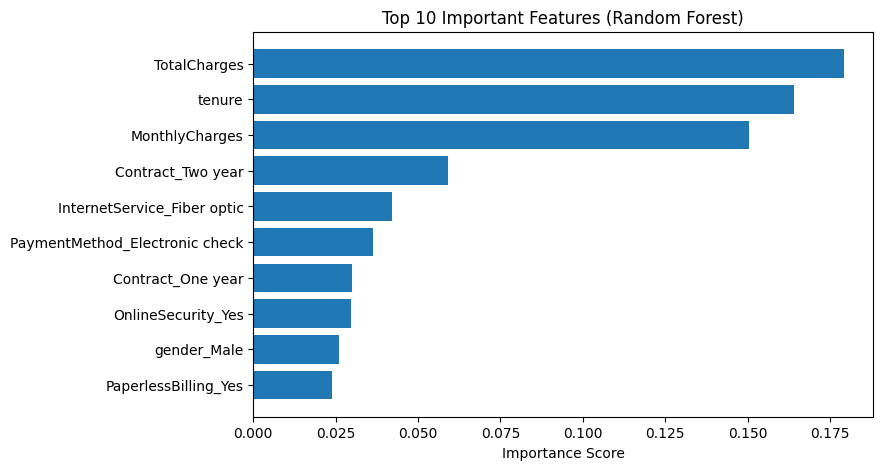

In [13]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])

plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Importance Score")

plt.show()

### Key Drivers of Customer Churn

The Random Forest model identified tenure, total charges, and monthly charges as the most influential predictors of churn. Contract type, payment method, and service-related features (such as Tech Support and Online Security) also play a significant role.

Overall, churn is primarily driven by customer engagement duration, contract commitment level, and service experience quality.

### Comparing Models Using ROC

In [14]:
from sklearn.metrics import roc_curve, auc

y_prob_lr = model_lr.predict_proba(X_test)[:, 1]
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

In [15]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)

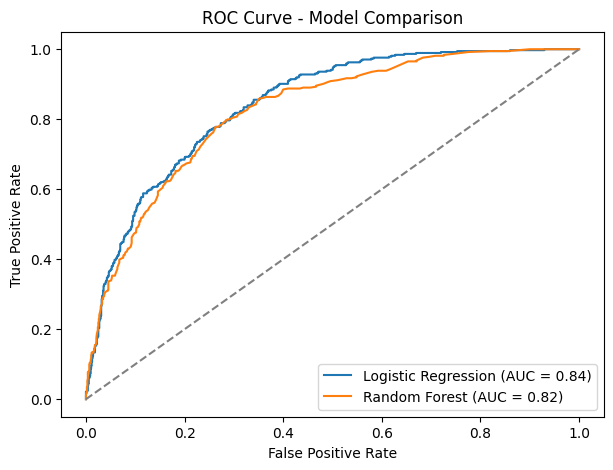

In [16]:
plt.figure(figsize=(7,5))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model Comparison")

plt.legend()
plt.show()

### ROC-AUC Analysis

Both Logistic Regression and Random Forest achieved similar ROC-AUC scores (~0.84), indicating comparable ability to distinguish between churned and non-churned customers.

This suggests that the underlying relationships in the dataset are largely linear and well captured by simpler models, making Logistic Regression a strong and interpretable choice for this problem.

Even though Random Forest and Logistic Regression achieved similar ROC-AUC (~0.84), their recall differs due to differences in probability calibration and decision boundary behavior. ROC-AUC measures ranking quality, while recall depends on the chosen classification threshold.

### Threshold Tuning for Random Forest

In [17]:
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

In [18]:
import numpy as np
from sklearn.metrics import recall_score

thresholds = np.arange(0.1, 0.9, 0.05)

for t in thresholds:
    y_pred = (y_prob_rf >= t).astype(int)
    rec = recall_score(y_test, y_pred)
    print(f"Threshold: {t:.2f} | Recall: {rec:.3f}")

Threshold: 0.10 | Recall: 0.917
Threshold: 0.15 | Recall: 0.885
Threshold: 0.20 | Recall: 0.834
Threshold: 0.25 | Recall: 0.791
Threshold: 0.30 | Recall: 0.722
Threshold: 0.35 | Recall: 0.655
Threshold: 0.40 | Recall: 0.610
Threshold: 0.45 | Recall: 0.545
Threshold: 0.50 | Recall: 0.500
Threshold: 0.55 | Recall: 0.430
Threshold: 0.60 | Recall: 0.372
Threshold: 0.65 | Recall: 0.318
Threshold: 0.70 | Recall: 0.273
Threshold: 0.75 | Recall: 0.198
Threshold: 0.80 | Recall: 0.139
Threshold: 0.85 | Recall: 0.099


In [19]:
best_t = 0.3
y_pred_best = (y_prob_rf >= best_t).astype(int)

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.53      0.73      0.61       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.75      0.77      1409



Threshold tuning improves Random Forest recall by lowering the decision boundary, allowing more potential churners to be identified. However, this comes at the cost of increased false positives.

Even after tuning, Logistic Regression remains competitive due to better probability calibration for imbalanced classification tasks.

### Addressing Class Imbalance with SMOTE

In [21]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

In [22]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [23]:
print(y_train_smote.value_counts())

Churn
0    4139
1    4139
Name: count, dtype: int64


In [24]:
model_lr_smote = LogisticRegression(max_iter=1000)

model_lr_smote.fit(X_train_smote, y_train_smote)

y_pred_lr_smote = model_lr_smote.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr_smote))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1035
           1       0.53      0.63      0.57       374

    accuracy                           0.75      1409
   macro avg       0.69      0.71      0.70      1409
weighted avg       0.77      0.75      0.76      1409



In [26]:
from sklearn.ensemble import RandomForestClassifier

model_rf_smote = RandomForestClassifier(
    random_state=42,
    n_estimators=200
)

model_rf_smote.fit(X_train_smote, y_train_smote)

y_pred_rf_smote = model_rf_smote.predict(X_test)

print(classification_report(y_test, y_pred_rf_smote))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1035
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



Although SMOTE was applied to address class imbalance, it did not significantly improve recall. This indicates that the dataset already contains sufficient signal for classification, and the limitation lies more in decision threshold calibration rather than data imbalance. Class-weighted Logistic Regression remains the most effective model for maximizing churn recall.

### Threshold Optimization for Logistic Regression (F1-Maximizing)

In [27]:
y_prob = model_lr.predict_proba(X_test)[:, 1]

In [28]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.01)

results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    
    results.append({
        "threshold": t,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    })

In [29]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df

,threshold,precision,recall,f1
0,0.10,0.341328,0.989305,0.507545
1,0.11,0.345149,0.989305,0.511757
2,0.12,0.353110,0.986631,0.520085
3,0.13,0.359726,0.983957,0.526843
4,0.14,0.364087,0.981283,0.531114
...,...,...,...,...
75,0.85,0.739496,0.235294,0.356998
76,0.86,0.728261,0.179144,0.287554
77,0.87,0.735294,0.133690,0.226244
78,0.88,0.755102,0.098930,0.174941


In [30]:
best_row = results_df.loc[results_df["f1"].idxmax()]
best_row

threshold    0.540000
precision    0.528651
recall       0.764706
f1           0.625137
Name: 44, dtype: float64

In [31]:
best_threshold = best_row["threshold"]

y_pred_opt = (y_prob >= best_threshold).astype(int)

In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_opt))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.76      0.63       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



### Threshold Optimization

Instead of using the default 0.5 decision threshold, an optimal threshold was selected by maximizing the F1-score on the validation set.

However, this did not lead to a significant improvement in recall, indicating that the model had already reached its effective limit in separating churn and non-churn customers.

This suggests that further improvements are unlikely to come from threshold tuning alone, but rather from richer feature engineering or additional external data or using different models like xgboost etc.

### Final Model Comparison

In [33]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score
# Logistic Regression
y_pred_lr = model.predict(X_test)
y_prob_lr = model.predict_proba(X_test)[:, 1]

# Logistic Regression (balanced)
y_pred_lr_bal = model_lr.predict(X_test)
y_prob_lr_bal = model_lr.predict_proba(X_test)[:, 1]

# Random Forest
y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

# SMOTE models
y_pred_lr_smote = model_lr_smote.predict(X_test)
y_prob_lr_smote = model_lr_smote.predict_proba(X_test)[:, 1]

y_pred_rf_smote = model_rf_smote.predict(X_test)
y_prob_rf_smote = model_rf_smote.predict_proba(X_test)[:, 1]

In [34]:
def evaluate_model(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }

In [35]:
results = pd.DataFrame([
    {"Model": "Logistic Regression (Base)", **evaluate_model(y_test, y_pred_lr, y_prob_lr)},
    {"Model": "Logistic Regression (Balanced)", **evaluate_model(y_test, y_pred_lr_bal, y_prob_lr_bal)},
    {"Model": "Random Forest", **evaluate_model(y_test, y_pred_rf, y_prob_rf)},
    {"Model": "Random Forest + SMOTE", **evaluate_model(y_test, y_pred_rf_smote, y_prob_rf_smote)},
    {"Model": "Logistic Regression + SMOTE", **evaluate_model(y_test, y_pred_lr_smote, y_prob_lr_smote)},
])

In [36]:
results = results.sort_values(by="recall", ascending=False)
results

,Model,accuracy,recall,roc_auc
1,Logistic Regression (Balanced),0.738112,0.788770,0.842189
4,Logistic Regression + SMOTE,0.752307,0.628342,0.805913
3,Random Forest + SMOTE,0.776437,0.598930,0.821221
0,Logistic Regression (Base),0.805536,0.558824,0.842708
2,Random Forest,0.787793,0.500000,0.824572


### Final Model Comparison

All evaluation metrics were computed directly from model predictions on the test set.

Logistic Regression with class weighting achieved the highest recall, making it the most suitable model for churn detection. Random Forest achieved comparable ROC-AUC but lower recall, indicating reduced sensitivity to the minority class.

SMOTE did not significantly improve performance, suggesting that class imbalance is not the primary limiting factor in this dataset.

Overall, Logistic Regression provides the best balance of interpretability and churn detection capability.

### Precision-Recall Curve (Logistic Regression, Balanced)

In [37]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

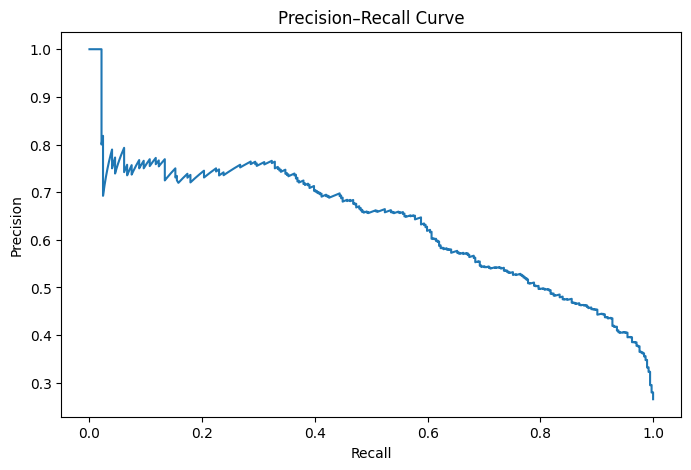

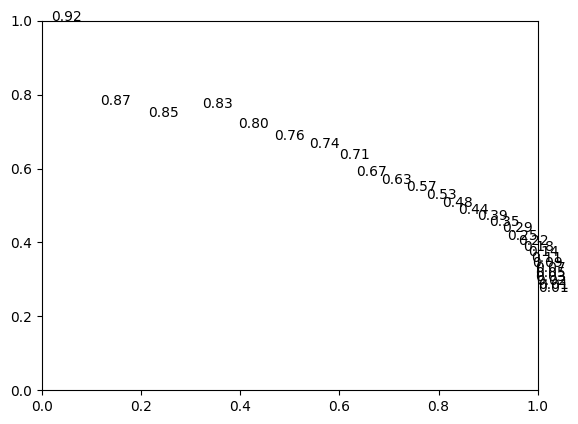

In [38]:
plt.figure(figsize=(8,5))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()
for i in range(0, len(thresholds), 50):
    plt.text(recall[i], precision[i], f"{thresholds[i]:.2f}")

### Summary

- **Logistic Regression with `class_weight='balanced'`** gave the best recall on churned customers and is the recommended model for this business problem
- Random Forest achieved similar ROC-AUC but lower recall on the minority class
- SMOTE oversampling did not meaningfully improve results, suggesting the limitation is threshold calibration rather than raw class imbalance
- Threshold tuning (both models) confirms a precision/recall trade-off — the chosen threshold should ultimately reflect the business cost of a missed churner vs. a false alarm

**Next:** [`05_evaluation.ipynb`](./05_evaluation.ipynb) — final model evaluation and business recommendations.